# Simulation of Power Demand of Machine Learning Workloads in 
# German HPC centers using pandapower




This notebook explains the methodology behind the simulation framework.  
It is written as a professional explanation document, not as a full source-code notebook.

The simulation combines:

- measured MLPerf workload traces,
- HPC center load modeling ,
- electrical grid modeling with `pandapower`,
- scenario analysis for power, cost, grid loading, and hosting capacity.

The purpose is to explain what the Simulation is doing from the first data sample until the final grid results.

## 1. Overall Methodology

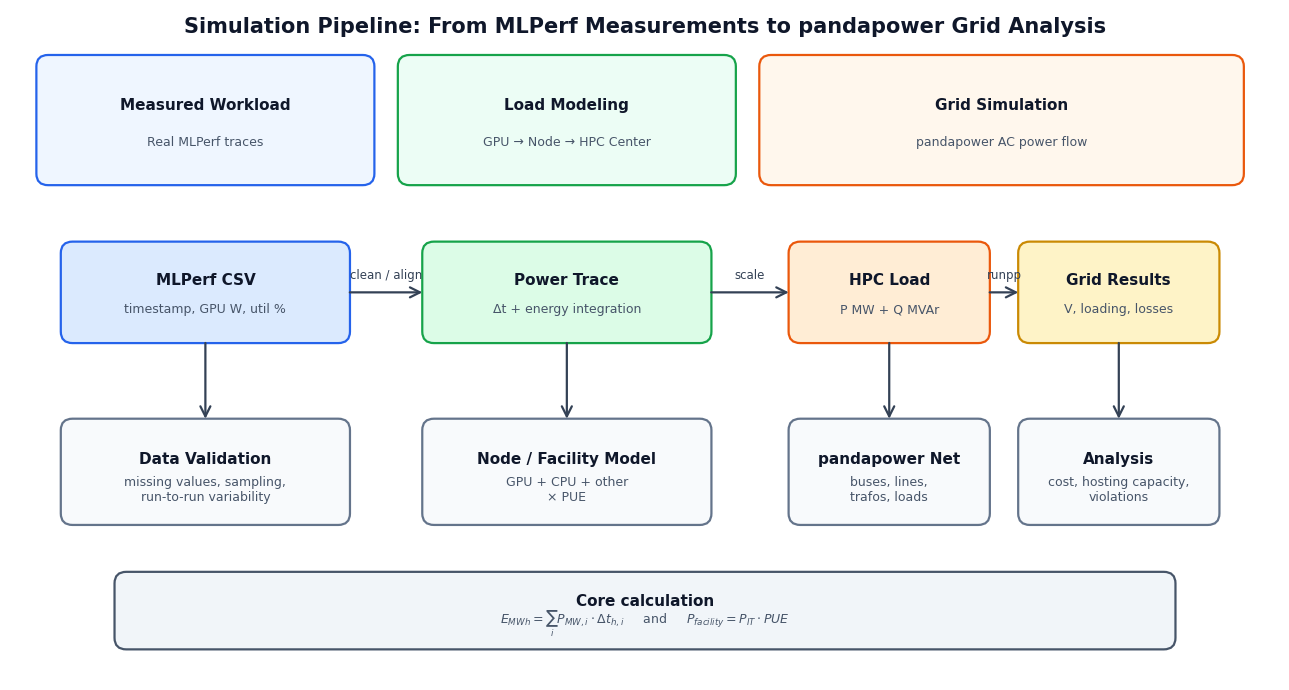

In [1]:
from IPython.display import Image, display

display(Image(filename='output.png'))

## 2. MLPerf Workload Data
The MLPerf CSV file is not directly used as grid input.  
First, the raw measurement data is cleaned and converted into a power time series.

The pipeline is:

```text
MLPerf CSV
→ clean timestamps                        
→ calculate Δt between samples
→ average / prepare GPU power trace
→ build node-level power
→ scale to HPC center power
→ convert W to MW
→ inject into pandapower as p_mw and q_mvar

## 3. Time Handling and Energy Integration

The simulation does not assume uniform sampling intervals.  
Instead, the time difference between consecutive samples is explicitly calculated:

$$
\Delta t_i = t_i - t_{i-1}
$$

This is necessary because the MLPerf measurements are not perfectly equidistant in time.

Energy is obtained by integrating power over time:

$$
E = \sum_i P_i \cdot \Delta t_i
$$

In the simulation, power is represented in megawatts (MW) and time in hours (h), resulting in:

$$
E_{\text{MWh}} = \sum_i P_{\text{MW},i} \cdot \Delta t_{\text{h},i}
$$

The total duration of a workload trace is therefore derived directly from the timestamps in the CSV file.  
As a result, a trace may span, for example, 1.04 hours instead of exactly 1 hour.

## 4. HPC Center Load Modeling 

Pandapower operates purely on electrical quantities and does not have any notion of GPUs or machine learning workloads.  
Therefore, the measured MLPerf workload must be transformed into an equivalent electrical load.

This transformation is performed in multiple steps:

```text
Measured GPU workload → node load → HPC center load → pandapower load


This abstraction allows complex computational workloads to be represented as time-varying electrical loads, enabling their impact on the power grid to be analyzed using standard power flow methods.

### 4.1 Node-Level Power Model

A compute node is modeled as the sum of its main components:

$$
P_{\text{node,IT}} = P_{\text{GPU}} + P_{\text{CPU}} + P_{\text{other}}
$$

where:
- $P_{\text{GPU}}$ is obtained from the MLPerf measurement,
- $P_{\text{CPU}}$ is estimated based on typical CPU consumption,
- $P_{\text{other}}$ includes memory, storage, and network components.

For example, assuming:
- average GPU power = 224.97 W,
- CPU power = 150 W,
- other components = 60 W,

the node-level IT power becomes:

$$
P_{\text{node,IT}} = 224.97 + 150 + 60 = 434.97 \ \text{W}
$$

### 4.2 Facility Power and PUE

Power Usage Effectiveness (PUE) accounts for additional energy consumption from cooling and facility infrastructure.

The facility power is calculated as:

$$
P_{\text{facility}} = P_{\text{IT}} \cdot \text{PUE}
$$

For a single node:

$$
P_{\text{node,facility}} = P_{\text{node,IT}} \cdot \text{PUE}
$$

Assuming:
- $P_{\text{node,IT}} = 434.97 \ \text{W}$
- $\text{PUE} = 1.30$

we obtain:

$$
P_{\text{node,facility}} = 434.97 \cdot 1.30 = 565.46 \ \text{W}
$$

Scaling to an HPC center with 10,000 nodes:

$$
P_{\text{total}} = 565.46 \cdot 10{,}000 = 5.65 \ \text{MW}
$$

This demonstrates how a workload measured at the GPU level (in watts) scales to a multi-megawatt electrical load when deployed in a large HPC center.

## 5. Training, Inference, and Simultaneous Workloads

<div style="display: flex; justify-content: align-items: center;">


<img src="jup11.png" width="17%">



</div>

The simulation supports three workload modes, each based on MLPerf power traces.

### Training Run
Training workloads exhibit high and relatively stable GPU utilization, resulting in sustained high power demand over time.

### Inference Run
Inference workloads are typically more dynamic and may show lower average utilization or shorter execution durations, depending on the benchmark configuration.

### Simultaneous Run
In the simultaneous mode, training and inference traces are combined to represent a mixed workload environment.

This is implemented by superposing the corresponding power time series:

$$
P_{\text{total}}(t) = P_{\text{train}}(t) + P_{\text{infer}}(t)
$$

This combined workload can lead to higher peak demand and increased stress on the electrical grid compared to individual workload types.

These modes enable a comparative analysis of how different ML workloads impact grid behavior and hosting capacity.

## 6. Extrapolation and Runtime Projections

If the measured workload trace is shorter than the intended simulation period, the workload must be extended.

Two approaches are supported:

1. **Fixed-duration projection**  
   The average power of the measured trace is used to estimate energy consumption over a specified time horizon:

   $$
   E = \bar{P} \cdot T
   $$

2. **Trace repetition**  
   The measured trace is treated as a representative workload pattern and repeated over time:

   $$
   P(t) = P_{\text{trace}}(t \bmod T_{\text{trace}})
   $$

The simulation does not assume that the measured segment represents a complete ML workload unless a full run has been captured.

Instead, the measured MLPerf trace is interpreted as a representative workload profile, which can be extrapolated to longer operating periods depending on the chosen method.

## 7. Grid Modeling with pandapower

Pandapower is used as the electrical simulation engine.  
It represents the power grid as a network of interconnected components:

| Component | Meaning |
|---|---|
| Bus | Electrical node / connection point |
| Line | Cable or overhead line |
| Transformer | Voltage-level conversion |
| Load | Electrical demand, e.g., HPC facility |
| External grid | Upstream grid / slack source |

The HPC workload is modeled as a time-varying electrical load and integrated into this network.

The simulation supports two types of grid models:

- **Synthetic HPC grid**  
  A simplified grid structure designed to represent a typical HPC facility connection (e.g., 110 kV → 20 kV → 0.4 kV).

- **SimBench grid**  
  A realistic benchmark grid provided by the pandapower ecosystem, representing typical German distribution networks.

This allows analyzing the impact of ML workloads under both controlled (synthetic) and realistic (benchmark) grid conditions.

<div style="display: flex; justify-content: space-between; align-items: center;">


<img src="jup2.png" width="45%">

<img src="jup3.png" width="50%">

</div>

## 8. What `pp.runpp(net)` Does

The core pandapower step is:

```python
pp.runpp(net)
```

This performs an AC power-flow calculation.  
Given the network topology, impedances, transformers, loads, and external grid, pandapower solves for:

- bus voltages,
- voltage angles,
- line currents,
- active and reactive power flows,
- transformer loading,
- grid losses,
- external-grid supply.

After running, pandapower fills result tables such as:

```text
net.res_bus      <>["vm_pu"] This shows voltage magnitude in per-unit. 
net.res_line     <>["loading_percent"] Line loading ---Values above 100% indicate overload.
net.res_trafo    <>["loading_percent"] Transformer loading  ---Values above 100% indicate transformer overload.
net.res_load
net.res_ext_grid <>["q_mvar"] Reactive power supports voltage and affects transformer and line loading.
```              <>["p_mw"] This indicates how much active power the upstream grid supplies or absorbs.

Reactive power and power factor
Reactive power is required for voltage support and electromagnetic operation of grid equipment.  
A low power factor means that the grid must carry more apparent power for the same useful active power.

These tables are the source of the electrical results shown in the dashboard.

## 10. Synthetic Grid vs SimBench Grid

### Synthetic HPC Grid

The synthetic grid is designed specifically for HPC-style scenarios.  
It usually contains a structured connection such as:

```text
External grid
→ 110 kV connection
→ transformer
→ 20 kV / 0.4 kV distribution
→ rack-level loads
```

This is useful for controlled experiments.

### SimBench Grid

SimBench provides German-style benchmark grids.  
These are not exact real German HPC-center grids, but they are realistic benchmark networks for reproducible grid studies.

When SimBench is selected, HPC loads are injected as additional demand into a benchmark grid.  
This allows testing how a German-style distribution grid reacts to large compute loads.


## 11. Scenario Modes

The simulation supports multiple scenario modes that modify the workload or its interpretation.

---

### Baseline

The measured workload is scaled to the selected HPC configuration without any optimization.  
This serves as the reference case for all comparisons.

---

### GPU Power Limit

GPU power is reduced by a scaling factor \(f \in (0,1]\).  
This lowers instantaneous power but may increase runtime depending on utilization.

A simple utilization-based performance model is:

$$
p(t) = 1 - \alpha \cdot u(t) \cdot (1 - f)
$$

where:
- \(p(t)\): performance factor (runtime impact),
- \(\alpha\): sensitivity parameter,
- \(u(t)\): GPU utilization,
- \(f\): GPU power factor.

This reflects the trade-off between reduced power and increased execution time.

---

### Improved Cooling

Cooling improvements reduce facility overhead by lowering the PUE.

Only the non-IT portion is affected:
- IT power remains unchanged  
- total facility power decreases

---

### Delayed Training

The workload is shifted in time without changing its shape or energy.

This does not reduce total energy consumption, but can reduce cost by moving execution into lower-price time periods.

---

### Interpretation

These scenarios allow separating different optimization strategies:
- **power reduction** (GPU cap)  
- **efficiency improvement** (PUE)  
- **time shifting** (delay)  

and analyzing their impact on grid load, energy consumption, and cost.

## 12. Cost and Time-of-Day Pricing

The cost of operating an HPC workload is calculated based on energy consumption and time-dependent electricity prices.

The general formulation is:

$$
\text{Cost} = \sum_i E_i \cdot \text{price}_i
$$

Since energy is derived from power over time, this can also be written as:

$$
\text{Cost} = \sum_i P_i \cdot \Delta t_i \cdot \text{price}_i
$$

---

### Time-of-Day Pricing

Electricity prices vary depending on the time of day.  
Therefore, the same workload can result in different total costs depending on when it is executed.

---

### Effect of Delayed Training

When training is delayed:

- total energy remains unchanged,
- the power profile is shifted in time,
- cost may change due to different tariff periods.


## 13. Workload Scheduling Across Centers

Scheduling controls how many HPC centers are active simultaneously and how workloads are distributed over time.

A key distinction must be made:

```text
Lower energy within a time window ≠ actual energy savings

## 14. Hosting Capacity Analysis

Hosting capacity answers:

> How many HPC centers can the selected grid support before a grid constraint is violated?

The app increases the number of HPC centers step by step and runs pandapower each time.

A configuration fails if:

- voltage falls below the allowed range,
- voltage rises above the allowed range,
- line loading exceeds 100%,
- transformer loading exceeds 100%,
- the power flow does not converge.

The first failing center count defines the limit of the grid under the selected assumptions.

## 15. Limitations

The simulation combines measured workload data with modeled system behavior and simplifying assumptions.

---

### Measured Components

- GPU power trace  
- GPU utilization  
- runtime of the recorded segment  

---

### Modeled Components

These are derived using structured models based on engineering assumptions:

- node-level power composition (GPU + CPU + other)  
- facility power via PUE  
- scaling to HPC center level  
- time-series load construction  
- workload scheduling and extrapolation  

---

### Assumed Components

These are fixed parameters that are not directly measured:

- CPU power consumption  
- memory, storage, and network power  
- Power Usage Effectiveness (PUE)  
- reactive power estimation (power factor)  
- grid topology and parameters  

---

### Grid Representation

SimBench grids are standardized benchmark networks representing typical German power systems.  
They are not exact models of real HPC-connected grids, but enable realistic and reproducible analysis.